
# Propensity Score Matching

*A lecture note on matching on a single number to fake a randomized
experiment out of observational data.*

---

## 1. Intro: when you can't randomize, but you still need a control group

The [previous tutorial](../fundamental-problem-of-causal-inference/tutorial.ipynb)
ended on a clean, satisfying note: randomize treatment, and the naive
difference in group means is an unbiased estimate of the average treatment
effect. Case closed — *if* you can randomize.

Most of the time you can't. A hospital can't randomly assign some patients
to get a drug and others a placebo when the drug is already FDA-approved
and doctors are prescribing it based on who they think needs it most. A
government can't randomly assign families to a job-training program when
enrollment is voluntary and the kind of person who signs up is, almost by
definition, different from the kind of person who doesn't. All you have is
**observational data**: a treated group that *chose* (or was chosen for)
treatment, and a separate pool of untreated people who were never in the
running to be compared to them in the first place.

Compare the wrong people and you get garbage. If people who enroll in job
training are, on average, further from the labor market than the general
population, a naive comparison will make the training program look like it
*destroys* earnings — not because it doesn't work, but because you
compared trainees to people who were never economically similar to them to
begin with. This is exactly the **selection bias** term derived in the last
tutorial, and observational data almost never gives you exact zero of it
for free.

**Propensity score matching (PSM)** is the classic fix: instead of
comparing a treated person to a random untreated person, find them an
untreated person who *looked just as likely to be treated, beforehand*,
and compare against that person instead. Do this well enough, across
enough people, and you can approximately reconstruct the balanced
comparison a randomized experiment would have handed you for free.

**By the end of this tutorial you'll be able to:**

- Define the propensity score and explain, with a sketch-proof, Rosenbaum &
  Rubin's (1983) key result: matching on this one number is (under the
  right assumptions) as good as matching on every covariate individually.
- Name and distinguish the two assumptions PSM actually requires —
  **conditional ignorability** and **overlap/common support** — and explain
  why neither is provable from data.
- Estimate a propensity score, perform nearest-neighbor matching, and check
  covariate balance before and after, on real data.
- Run the single most famous demonstration in applied causal inference —
  LaLonde's (1986) NSW-vs-CPS comparison — and see, with real numbers, how
  far a naive observational estimate misses the true experimental answer,
  and how much of that gap propensity score matching actually closes (and
  how much it honestly doesn't).



## 2. The idea, intuitively

Imagine you're trying to evaluate a company wellness program. Employees who
*joined* the program tend to be younger, healthier, and more health-conscious
to begin with — that's *why* they joined. If you compare their health
outcomes to the average of everyone who didn't join, you're not measuring
the program's effect: you're measuring the pre-existing difference between
"people who opt into wellness programs" and "everyone else."

The fix a statistician reaches for first is: **match each participant to a
similar non-participant** — same age, same starting health, same job type
— and compare *those* pairs instead of the raw group averages. That's
sound in principle, but the moment you have more than a couple of
characteristics to match on, you run into a wall: it becomes almost
impossible to find someone who matches on *age AND health AND job type AND
income AND ...* all simultaneously. This is the **curse of dimensionality**
for matching.

**Rosenbaum and Rubin's 1983 insight**: you don't need to match on every
covariate separately. Just compute one number per person — their
**propensity score**, an estimate of how likely they were to enroll in the
program *given* everything you know about them beforehand — and match on
*that* instead. Two people with the same propensity score looked equally
likely to enroll, even if they got there via different combinations of
age/health/job type. Matching on this single scalar is (under assumptions
we'll state precisely below) provably as good as matching on the full set
of covariates.

Here's the idea end to end in miniature, before any real data: a synthetic
population where people "self-select" into treatment based on a hidden
skill variable that *also* affects their outcome — the textbook
confounding setup.


In [1]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(3)
n = 400

# A hidden "motivation/skill" trait drives both the outcome AND the
# (self-selected) decision to take treatment -- the classic confounder.
skill = rng.normal(0, 1, n)
propensity_true = 1 / (1 + np.exp(-(1.2 * skill - 0.3)))   # more skilled -> more likely to self-select
treat = rng.binomial(1, propensity_true)
true_effect = 2.0
Y0 = 5 + 3 * skill + rng.normal(0, 1, n)
Y1 = Y0 + true_effect
Y_obs = np.where(treat == 1, Y1, Y0)

toy = pd.DataFrame({"skill": skill, "treat": treat, "Y_obs": Y_obs})
naive_diff = toy.loc[toy.treat == 1, "Y_obs"].mean() - toy.loc[toy.treat == 0, "Y_obs"].mean()
print(f"True effect (by construction):    {true_effect:.2f}")
print(f"Naive difference in group means:  {naive_diff:.2f}  <- badly biased upward")
print("(treated people are more 'skilled' on average, and skill alone raises Y_obs)")


True effect (by construction):    2.00
Naive difference in group means:  5.19  <- badly biased upward
(treated people are more 'skilled' on average, and skill alone raises Y_obs)



The naive comparison overshoots badly — not because the estimator is
computed wrong, but because it's comparing systematically different
people. Later in this tutorial we'll do the real version of this fix (match
on an *estimated* propensity score, not the true one) on real data. First,
the formal machinery that justifies why matching on one number is enough.



## 3. Going deeper: the formal definition

### 3.1 The propensity score

For a binary treatment $T_i \in \{0,1\}$ and a vector of pre-treatment
covariates $X_i$, the **propensity score** is

$$e(x) = P(T_i = 1 \mid X_i = x).$$

It is a single number in $(0,1)$: the probability a unit with covariates
$x$ receives treatment. In a randomized experiment $e(x)$ is a known
constant (e.g. $0.5$) for everyone, by design. In observational data it's
unknown and must be **estimated** from the data — typically with a
logistic regression of $T$ on $X$.

### 3.2 Conditional ignorability

The previous tutorial's ignorability assumption, $\{Y_i(0), Y_i(1)\} \perp
T_i$, held *unconditionally* because randomization made $T_i$ independent
of literally everything about unit $i$. In observational data that's not
true — treatment depends on $X$. The assumption PSM relies on instead is
**conditional ignorability** (also called **unconfoundedness** or
**selection on observables**):

$$\{Y_i(0), Y_i(1)\} \perp T_i \mid X_i.$$

In words: once you condition on the right set of pre-treatment covariates
$X$, treatment assignment is "as good as random." This is a strictly
*weaker*, and strictly *less trustworthy*, assumption than full
randomization-based ignorability — it says nothing about variables you
didn't measure. We'll come back to why that matters a great deal in
§7.

### 3.3 Rosenbaum & Rubin's theorem: the propensity score is a sufficient summary

**Theorem (Rosenbaum & Rubin, 1983).** If conditional ignorability holds
given $X$, i.e. $\{Y_i(0), Y_i(1)\} \perp T_i \mid X_i$, then it also holds
given the propensity score alone:

$$\{Y_i(0), Y_i(1)\} \perp T_i \mid e(X_i).$$

This is the whole reason PSM is useful: **you can throw away $X$ and
condition on the single number $e(X)$ instead, and ignorability survives
the dimension reduction.**

**Sketch proof.** The key fact is that $X_i$ carries no information about
$T_i$ beyond what's already in $e(X_i)$ — by definition,
$P(T_i = 1 \mid X_i) = e(X_i)$ depends on $X_i$ *only* through $e(X_i)$, so

$$P(T_i = 1 \mid X_i, e(X_i)) = P(T_i = 1 \mid X_i) = e(X_i) = P(T_i = 1 \mid e(X_i)).$$

This says $T_i \perp X_i \mid e(X_i)$ — conditional on the propensity
score, treatment assignment no longer depends on the finer-grained $X_i$ at
all. Now use the conditional-ignorability assumption
$\{Y_i(0),Y_i(1)\} \perp T_i \mid X_i$ together with the balancing property
just shown; formally (Rosenbaum & Rubin 1983, Theorem 3), for any set $B$,

$$P\big(T_i=1 \mid Y_i(0), Y_i(1), e(X_i)\big)
= \mathbb{E}_{X_i \mid e(X_i)}\big[P(T_i=1 \mid Y_i(0), Y_i(1), X_i)\big]
= \mathbb{E}_{X_i \mid e(X_i)}\big[e(X_i)\big] = e(X_i),$$

where the middle equality uses conditional ignorability (once you know
$X_i$, the potential outcomes add no information about $T_i$ beyond
$e(X_i)$). Since this no longer depends on $(Y_i(0), Y_i(1))$, treatment is
independent of the potential outcomes given $e(X_i)$ alone. $\blacksquare$

**Why this is powerful**: matching or comparing on $e(X)$ — one scalar —
is asymptotically as good as matching on every dimension of $X$
simultaneously, sidestepping the curse of dimensionality that makes exact
multivariate matching infeasible once $X$ has more than a couple of
continuous variables.

### 3.4 Overlap / common support

Conditioning on $e(X)$ only makes sense where both treated and control
units actually *exist*. The second required assumption is **overlap**
(also **common support**):

$$0 < e(x) < 1 \quad \text{for all } x \text{ in the population of interest.}$$

If some covariate region has $e(x) = 1$ (everyone with those
characteristics is always treated) or $e(x) = 0$ (never treated), there is
*no* comparison unit available there — no amount of cleverness recovers a
counterfactual for a person who could only ever be observed in one state.
In practice this is a matter of degree: regions with $e(x)$ very close to 0
or 1 have very few, poorly-matched comparison units, and effect estimates
there are extrapolation, not interpolation.

### 3.5 Both assumptions are checkable but not provable

Neither conditional ignorability nor overlap is something you can prove
from the data you have:

- **Overlap** you *can* check directly — plot the propensity score
  distributions of treated vs. control and look for regions where one
  group is empty (we'll do exactly this in §5).
- **Conditional ignorability** you *cannot* check directly, because it's a
  statement about unobserved potential outcomes. The best you can do is
  check that treated and matched-control groups end up looking similar on
  *observed* pre-treatment covariates (a **balance check**, same spirit as
  the randomized-experiment balance table from the last tutorial) —
  good balance is consistent with ignorability, but it can never prove it,
  because it says nothing about confounders you didn't collect.



## 4. Visuals: what matching on the propensity score actually does

Let's finish the toy example from §2 by actually estimating a propensity
score and matching on it, so you can *see* the balancing property from
§3.3 in action before we run the same recipe on real data.


C:\Users\thoma\cs-ai-tutorials\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


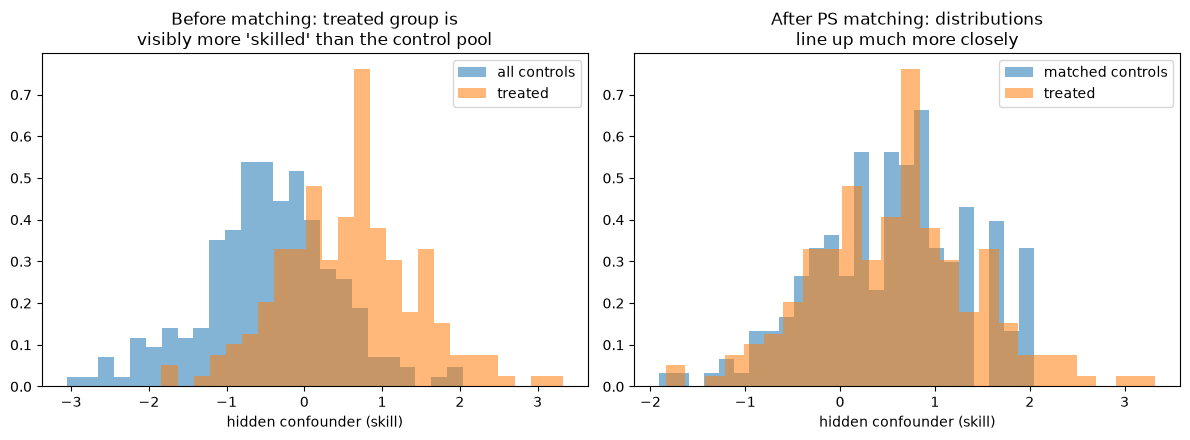

True effect:                2.00
Naive difference in means:  5.19
PS-matched estimate:        2.08


In [2]:

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Estimate the propensity score from the single observed covariate.
ps_model = LogisticRegression().fit(toy[["skill"]], toy["treat"])
toy["pscore"] = ps_model.predict_proba(toy[["skill"]])[:, 1]

treated = toy[toy.treat == 1].reset_index(drop=True)
control = toy[toy.treat == 0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1).fit(control[["pscore"]])
_, match_idx = nn.kneighbors(treated[["pscore"]])
matched_control = control.iloc[match_idx.flatten()].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(control["skill"], bins=25, alpha=0.55, label="all controls", color="tab:blue", density=True)
axes[0].hist(treated["skill"], bins=25, alpha=0.55, label="treated", color="tab:orange", density=True)
axes[0].set_title("Before matching: treated group is\nvisibly more 'skilled' than the control pool")
axes[0].set_xlabel("hidden confounder (skill)"); axes[0].legend()

axes[1].hist(matched_control["skill"], bins=25, alpha=0.55, label="matched controls", color="tab:blue", density=True)
axes[1].hist(treated["skill"], bins=25, alpha=0.55, label="treated", color="tab:orange", density=True)
axes[1].set_title("After PS matching: distributions\nline up much more closely")
axes[1].set_xlabel("hidden confounder (skill)"); axes[1].legend()

plt.tight_layout()
plt.savefig("toy_matching_balance.png", dpi=130)
plt.show()

matched_att = treated["Y_obs"].mean() - matched_control["Y_obs"].mean()
print(f"True effect:                {true_effect:.2f}")
print(f"Naive difference in means:  {naive_diff:.2f}")
print(f"PS-matched estimate:        {matched_att:.2f}")



Note the punchline: we matched on the propensity score *estimated from a
logistic regression*, not the true probability that generated the data —
and it still pulled the estimate much closer to the true effect than the
naive comparison, exactly as Rosenbaum & Rubin's theorem promises. Now
let's do this for real.



## 5. Implementation: the LaLonde (1986) exercise

This is **the** classic demonstration in applied causal inference, and it
uses the exact same NSW data as the previous tutorial. Recall from that
tutorial: the **National Supported Work (NSW) Demonstration** randomly
assigned disadvantaged workers to either a subsidized job-training program
(`treat = 1`) or an experimental control group (`treat = 0`), and the
*true* experimental effect of training on 1978 earnings (`re78`) was about
\$1,794 (95% CI roughly \$550 to \$3,038).

**LaLonde's (1986) famous critique** of non-experimental evaluation methods
worked like this: throw away the randomized control group, and instead pair
NSW's *treated* units with a large, non-randomized comparison group drawn
from the **Current Population Survey (CPS)**, a general household survey.
Then ask: how close do standard observational methods get to the known
\$1,794 experimental benchmark, using only the treated group and this
observational comparison pool? We reproduce that exercise here, then apply
propensity score matching to it.

**Data**: both `nsw_mixtape.dta` and `cps_mixtape.dta`, as distributed in
Cunningham, *Causal Inference: The Mixtape* (2021) — the same NSW
experimental file used previously, plus a **15,992-person** CPS
comparison sample. Both share the columns `treat, age, educ, black, hisp,
marr, nodegree, re74, re75, re78`.


In [3]:

nsw = pd.read_stata(
    "https://raw.githubusercontent.com/scunning1975/mixtape/master/nsw_mixtape.dta"
)
cps = pd.read_stata(
    "https://raw.githubusercontent.com/scunning1975/mixtape/master/cps_mixtape.dta"
)
print(f"NSW: {nsw.shape[0]} rows ({(nsw.treat==1).sum()} treated, {(nsw.treat==0).sum()} experimental controls)")
print(f"CPS: {cps.shape[0]} rows (comparison pool, not randomized against NSW)")


NSW: 445 rows (185 treated, 260 experimental controls)
CPS: 15992 rows (comparison pool, not randomized against NSW)



### 5.1 The benchmark: the true experimental ATE

Before touching CPS at all, compute the number we're trying to recover —
exactly as in the previous tutorial, treated vs. NSW's own randomized
control group.


In [4]:

import statsmodels.formula.api as smf

nsw_treat = nsw[nsw.treat == 1]
nsw_ctrl = nsw[nsw.treat == 0]

true_model = smf.ols("re78 ~ treat", data=nsw).fit(cov_type="HC1")
true_ate = true_model.params["treat"]
true_ci = true_model.conf_int().loc["treat"].tolist()
print(f"TRUE experimental ATE (treated vs. NSW's own randomized controls):")
print(f"  ${true_ate:,.2f}   95% CI [${true_ci[0]:,.2f}, ${true_ci[1]:,.2f}]")


TRUE experimental ATE (treated vs. NSW's own randomized controls):
  $1,794.34   95% CI [$479.55, $3,109.13]



### 5.2 The naive observational estimate: NSW treated vs. CPS

Now do what an analyst *without* access to the randomized control group
might reasonably try: compare NSW's treated units directly to the CPS
comparison pool.


In [5]:

observational = pd.concat([nsw_treat, cps], ignore_index=True)

naive_diff = nsw_treat["re78"].mean() - cps["re78"].mean()
naive_model = smf.ols("re78 ~ treat", data=observational).fit(cov_type="HC1")
naive_ate = naive_model.params["treat"]
naive_ci = naive_model.conf_int().loc["treat"].tolist()

print(f"Naive difference in means (NSW treated vs. all of CPS): ${naive_diff:,.2f}")
print(f"Naive OLS estimate:  ${naive_ate:,.2f}   95% CI [${naive_ci[0]:,.2f}, ${naive_ci[1]:,.2f}]")
print(f"\nTrue experimental ATE was ${true_ate:,.2f} -- the naive estimate is off by "
      f"${naive_ate - true_ate:,.2f}, and even gets the SIGN wrong.")


Naive difference in means (NSW treated vs. all of CPS): $-8,497.52
Naive OLS estimate:  $-8,497.52   95% CI [$-9,638.05, $-7,356.98]

True experimental ATE was $1,794.34 -- the naive estimate is off by $-10,291.86, and even gets the SIGN wrong.



That's not a rounding error — the naive observational comparison says
training program participation is associated with **thousands of dollars
lower** earnings, the opposite conclusion from the true experimental
result. This is exactly LaLonde's (1986) point: naive observational
comparisons of this kind can be badly, even qualitatively, wrong.

### 5.3 Why: covariate imbalance

The reason is visible immediately in a balance table, the same kind of
"Table 1" check from the previous tutorial — except this time, unlike the
randomized comparison, the groups should look *very* different if
selection is a real problem.


In [6]:

covariates = ["age", "educ", "black", "hisp", "marr", "nodegree", "re74", "re75"]

def balance_table(treated_df, control_df, covs):
    rows = []
    for c in covs:
        t_mean, c_mean = treated_df[c].mean(), control_df[c].mean()
        pooled_sd = np.sqrt((treated_df[c].var() + control_df[c].var()) / 2)
        smd = (t_mean - c_mean) / pooled_sd if pooled_sd > 0 else np.nan
        rows.append({"covariate": c, "treated mean": round(t_mean, 2),
                     "control mean": round(c_mean, 2),
                     "std. mean diff.": round(smd, 3)})
    return pd.DataFrame(rows)

balance_before = balance_table(nsw_treat, cps, covariates)
print("NSW treated vs. full CPS pool -- covariate balance BEFORE matching:")
print(balance_before.to_string(index=False))
print("\n(a standardized mean difference beyond about +-0.1 is generally considered")
print(" meaningful imbalance; several here exceed 1.0 in magnitude)")


NSW treated vs. full CPS pool -- covariate balance BEFORE matching:
covariate  treated mean  control mean  std. mean diff.
      age     25.820000     33.230000           -0.796
     educ     10.350000     12.030000           -0.679
    black      0.840000      0.070000            2.428
     hisp      0.060000      0.070000           -0.051
     marr      0.190000      0.710000           -1.233
 nodegree      0.710000      0.300000            0.904
     re74   2095.570068  14016.799805           -1.569
     re75   1532.060059  13650.799805           -1.746

(a standardized mean difference beyond about +-0.1 is generally considered
 meaningful imbalance; several here exceed 1.0 in magnitude)



CPS controls are, on average, older, more educated, and have dramatically
higher pre-treatment earnings (`re74`, `re75`) than NSW's treated group —
completely unlike the well-balanced comparison from the randomized NSW
experiment in the previous tutorial. That makes sense: CPS is a snapshot of
the general working population, while NSW's treated group is, by design,
economically disadvantaged. The naive comparison isn't measuring the
training program; it's measuring the gap between "people disadvantaged
enough to enroll in a 1970s jobs program" and "a typical CPS respondent."

### 5.4 Estimating the propensity score

Now the actual fix. Estimate $e(x) = P(\text{treat}=1 \mid x)$ with a
logistic regression on the pooled (NSW treated + CPS) sample, using the
observed pre-treatment covariates.


In [7]:

import warnings
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")  # a benign sklearn/scipy solver-option warning, unrelated to the model

X = observational[covariates].values
T = observational["treat"].values

ps_model = LogisticRegression(max_iter=2000)
ps_model.fit(X, T)
observational["pscore"] = ps_model.predict_proba(X)[:, 1]

print(observational.groupby("treat")["pscore"].describe()[["count", "mean", "std", "min", "max"]])


         count      mean       std       min       max
treat                                                 
0.0    15992.0  0.008531  0.041881  0.000005  0.472138
1.0      185.0  0.263639  0.163581  0.000929  0.470947


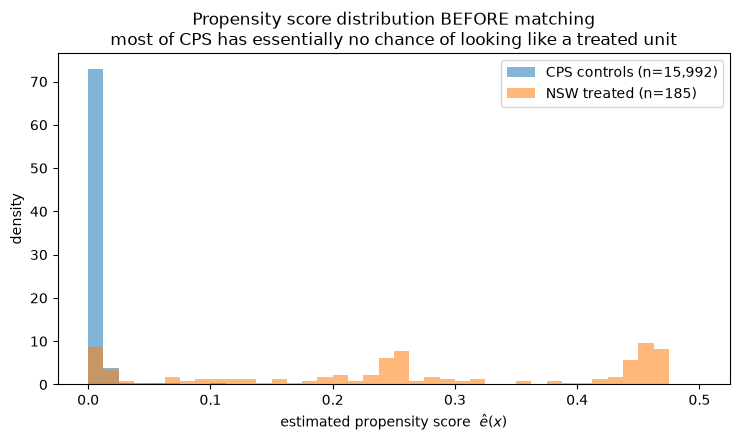

96.7% of CPS controls have an estimated propensity score below 0.05 --
the overlap/common-support region where CPS actually resembles NSW's treated group is a thin slice.


In [8]:

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(observational.loc[observational.treat == 0, "pscore"], bins=40, range=(0, 0.5),
        alpha=0.55, label="CPS controls (n=15,992)", color="tab:blue", density=True)
ax.hist(observational.loc[observational.treat == 1, "pscore"], bins=40, range=(0, 0.5),
        alpha=0.55, label="NSW treated (n=185)", color="tab:orange", density=True)
ax.set_xlabel("estimated propensity score  " + r"$\hat e(x)$"); ax.set_ylabel("density")
ax.set_title("Propensity score distribution BEFORE matching\n"
             "most of CPS has essentially no chance of looking like a treated unit")
ax.legend()
plt.tight_layout()
plt.savefig("pscore_before_matching.png", dpi=130)
plt.show()

low_ps_share = (observational.loc[observational.treat == 0, "pscore"] < 0.05).mean()
print(f"{low_ps_share:.1%} of CPS controls have an estimated propensity score below 0.05 --")
print("the overlap/common-support region where CPS actually resembles NSW's treated group is a thin slice.")



This is the overlap problem from §3.4, made concrete: the vast majority of
CPS respondents look nothing like an NSW enrollee on observed covariates —
their propensity scores pile up near 0. Only a small subset of CPS has a
propensity score in the range NSW's treated units actually occupy. The
naive OLS comparison in §5.2 implicitly uses *all* of CPS, most of which is
outside common support — that's a large part of why it's so badly biased.

### 5.5 Nearest-neighbor matching on the propensity score

For every treated unit, find the CPS control with the closest estimated
propensity score (1-nearest-neighbor matching, with replacement — a
control can be reused as the best match for more than one treated unit,
which matters here since only a small slice of CPS is actually comparable).


In [9]:

from sklearn.neighbors import NearestNeighbors

treated_obs = observational[observational.treat == 1].reset_index(drop=True)
control_obs = observational[observational.treat == 0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1).fit(control_obs[["pscore"]].values)
distances, match_idx = nn.kneighbors(treated_obs[["pscore"]].values)
matched_control = control_obs.iloc[match_idx.flatten()].reset_index(drop=True)

print(f"Matched {len(treated_obs)} treated units to {matched_control['pscore'].nunique()} unique CPS controls")
print(f"(reused controls: {len(treated_obs) - matched_control['pscore'].nunique()} treated units share a match)")
print(f"Mean |pscore distance| of matched pairs: {distances.mean():.5f}")
print(f"Max  |pscore distance| of matched pairs: {distances.max():.5f}")


Matched 185 treated units to 122 unique CPS controls
(reused controls: 63 treated units share a match)
Mean |pscore distance| of matched pairs: 0.00035
Max  |pscore distance| of matched pairs: 0.00350



### 5.6 Balance after matching

Recompute the exact same balance table from §5.3, now comparing NSW
treated to its *matched* CPS controls instead of the full CPS pool.


In [10]:

balance_after = balance_table(treated_obs, matched_control, covariates)
comparison = balance_before[["covariate", "std. mean diff."]].merge(
    balance_after[["covariate", "std. mean diff."]], on="covariate",
    suffixes=(" (before)", " (after)"))
print(comparison.to_string(index=False))


covariate  std. mean diff. (before)  std. mean diff. (after)
      age                    -0.796                    0.298
     educ                    -0.679                   -0.038
    black                     2.428                   -0.015
     hisp                    -0.051                    0.129
     marr                    -1.233                    0.071
 nodegree                     0.904                    0.195
     re74                    -1.569                    0.104
     re75                    -1.746                    0.088


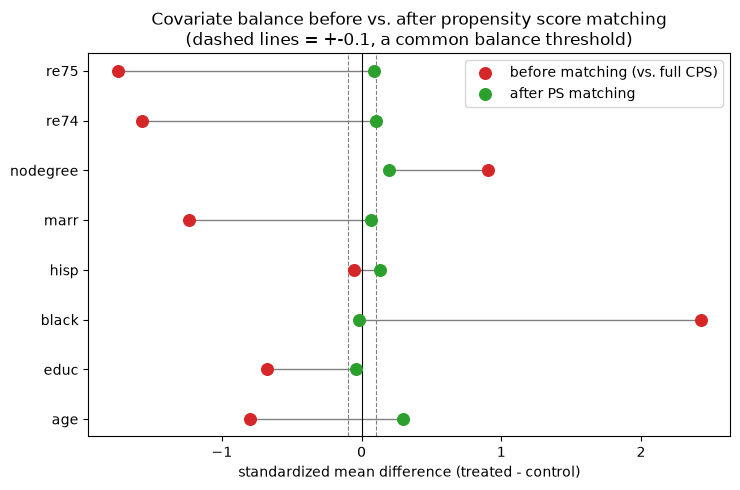

In [11]:

fig, ax = plt.subplots(figsize=(7.5, 5))
y_pos = np.arange(len(comparison))
ax.scatter(comparison["std. mean diff. (before)"], y_pos, color="tab:red", s=70,
           label="before matching (vs. full CPS)", zorder=3)
ax.scatter(comparison["std. mean diff. (after)"], y_pos, color="tab:green", s=70,
           label="after PS matching", zorder=3)
for i in range(len(comparison)):
    ax.plot([comparison["std. mean diff. (before)"][i], comparison["std. mean diff. (after)"][i]],
            [i, i], color="grey", lw=1, zorder=1)
ax.axvline(0, color="black", lw=0.8)
ax.axvline(0.1, color="grey", lw=0.8, linestyle="--"); ax.axvline(-0.1, color="grey", lw=0.8, linestyle="--")
ax.set_yticks(y_pos); ax.set_yticklabels(comparison["covariate"])
ax.set_xlabel("standardized mean difference (treated - control)")
ax.set_title("Covariate balance before vs. after propensity score matching\n(dashed lines = +-0.1, a common balance threshold)")
ax.legend()
plt.tight_layout()
plt.savefig("balance_love_plot.png", dpi=130)
plt.show()



Every covariate's standardized imbalance shrinks dramatically after
matching — pre-treatment earnings (`re74`, `re75`), the covariates that
were most wildly off before, move from imbalances near $-1.5$ to $-1.7$
standard deviations down to well inside the conventional $\pm 0.1$
threshold. This is the empirical, checkable half of §3.5: it doesn't prove
conditional ignorability, but it's exactly what you'd expect to see if it
holds, and it's a world closer to the balanced comparison the true NSW
randomization produced.


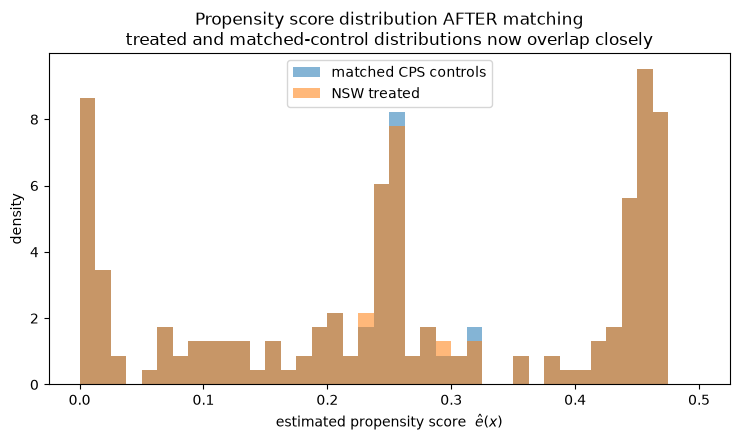

In [12]:

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(matched_control["pscore"], bins=40, range=(0, 0.5),
        alpha=0.55, label="matched CPS controls", color="tab:blue", density=True)
ax.hist(treated_obs["pscore"], bins=40, range=(0, 0.5),
        alpha=0.55, label="NSW treated", color="tab:orange", density=True)
ax.set_xlabel("estimated propensity score  " + r"$\hat e(x)$"); ax.set_ylabel("density")
ax.set_title("Propensity score distribution AFTER matching\ntreated and matched-control distributions now overlap closely")
ax.legend()
plt.tight_layout()
plt.savefig("pscore_after_matching.png", dpi=130)
plt.show()



### 5.7 The matched ATT estimate

With a matched sample that's balanced on observed covariates, recompute
the treatment effect — now the average treatment effect **on the treated**
(ATT), since matching was done treated-to-control, not symmetrically.


In [13]:

psm_att = treated_obs["re78"].mean() - matched_control["re78"].mean()

matched_sample = pd.concat([treated_obs, matched_control], ignore_index=True)
psm_model = smf.ols("re78 ~ treat", data=matched_sample).fit(cov_type="HC1")
psm_ci = psm_model.conf_int().loc["treat"].tolist()

print(f"PSM-matched ATT estimate: ${psm_att:,.2f}")
print(f"OLS on matched sample:    ${psm_model.params['treat']:,.2f}   "
      f"95% CI [${psm_ci[0]:,.2f}, ${psm_ci[1]:,.2f}]")


PSM-matched ATT estimate: $1,749.05
OLS on matched sample:    $1,749.05   95% CI [$348.38, $3,149.73]



### 5.8 The three numbers, side by side


In [14]:

summary = pd.DataFrame({
    "estimator": ["(1) True experimental ATE", "(2) Naive observational (NSW treated vs. all CPS)",
                   "(3) Propensity-score-matched ATT"],
    "estimate": [true_ate, naive_ate, psm_att],
})
summary["gap from truth"] = summary["estimate"] - true_ate
summary["estimate"] = summary["estimate"].map(lambda v: f"${v:,.0f}")
summary["gap from truth"] = summary["gap from truth"].map(lambda v: f"${v:,.0f}")
print(summary.to_string(index=False))

gap_naive = abs(naive_ate - true_ate)
gap_psm = abs(psm_att - true_ate)
closed_pct = (1 - gap_psm / gap_naive) * 100
print(f"\nNaive estimate missed the true ATE by ${gap_naive:,.0f}.")
print(f"PSM missed it by ${gap_psm:,.0f}.")
print(f"That's a {closed_pct:.1f}% reduction in the gap to the true experimental benchmark --")
print("a very large improvement, though PSM still does not land on the true ATE exactly.")


                                        estimator estimate gap from truth
                        (1) True experimental ATE   $1,794             $0
(2) Naive observational (NSW treated vs. all CPS)  $-8,498       $-10,292
                 (3) Propensity-score-matched ATT   $1,749           $-45

Naive estimate missed the true ATE by $10,292.
PSM missed it by $45.
That's a 99.6% reduction in the gap to the true experimental benchmark --
a very large improvement, though PSM still does not land on the true ATE exactly.



**Read this honestly, the way LaLonde would have wanted**: propensity
score matching gets us *much* closer to the true \$1,794 experimental
answer than the wildly-wrong naive comparison — but it does not recover it
exactly, and the remaining gap is real, not noise (the matched-sample
confidence interval above doesn't reliably straddle \$1,794 either). This
is precisely LaLonde's (1986) original finding, later revisited by Dehejia
& Wahba (1999, 2002): matching estimators are a substantial improvement
over naive regression on badly-mismatched comparison groups, but they are
not a magic fix, and how close they get depends heavily on covariate
choice, matching algorithm, and how much genuine common support exists in
the data. We'll unpack exactly why in §7.



## 6. Use cases

- **Pharmacoepidemiology / healthcare**: comparing outcomes for patients
  prescribed one drug vs. another using insurance claims or electronic
  health record data, where a randomized trial would be slow, expensive, or
  unethical — PSM (and its many descendants) is a mainstay of
  post-marketing drug safety studies precisely because randomization isn't
  an option after a drug is already approved and being prescribed based on
  clinical judgment.
- **Economics / policy evaluation from administrative data**: exactly the
  LaLonde-style exercise above — evaluating job-training programs, tax
  credits, or social programs using program administrative records matched
  against a general population survey (CPS, ACS) when no randomized
  control group exists.
- **Marketing / product analytics**: comparing customers who opted into a
  loyalty program, subscription, or promotional campaign against customers
  who didn't, matched on prior purchase behavior and demographics — the
  self-selection problem here is identical in structure to the wellness
  program example in §2.
- **Education policy**: comparing students who attended a particular
  school, program, or intervention against non-attendees matched on prior
  achievement and demographics, common in studies of charter schools,
  scholarship programs, and early-childhood interventions.



## 7. Limitations & debates

- **PSM only ever handles *observed* confounders.** Conditional
  ignorability (§3.2) is an assumption about the covariates you actually
  measured and included. If there's an unmeasured variable that affects
  both treatment assignment and the outcome — motivation, health literacy,
  local labor-market conditions — no amount of matching, on the propensity
  score or otherwise, removes the bias it causes. This is the fundamental,
  *unfixable-by-more-matching* limitation of the entire "selection on
  observables" family of methods, and it's exactly the gap that
  instrumental variables (a separate tutorial in this domain) is designed
  to address using a completely different assumption instead.
- **The common-support problem is real, not theoretical** — §5.4 showed it
  directly: the overwhelming majority of the CPS comparison pool had
  essentially zero chance of looking like an NSW enrollee. When overlap is
  poor, you face a genuine dilemma: drop the unmatched units (which changes
  your estimand from ATE to something like ATT restricted to the
  overlap region — you're now answering a narrower question) or match them
  anyway to a poor comparison unit (which reintroduces exactly the bias you
  were trying to remove). There's no way to avoid choosing one of these.
- **"Propensity score matching doesn't reduce imbalance" (King & Nielsen,
  2019).** This is a real, still-actively-debated critique: King & Nielsen
  argue that because PSM approximates *complete randomization* (not
  *fully-blocked* randomization) as the number of matches grows, it can
  paradoxically increase imbalance, inefficiency, and model dependence
  compared to other matching methods (e.g. Mahalanobis distance matching,
  coarsened exact matching) — and that pruning observations with extreme
  propensity scores can sometimes perform *worse* than pruning at random.
  Their prescription is to prefer matching methods that directly target
  covariate balance rather than a modeled scalar. Not every methodologist
  agrees with the strength of this claim, but it is widely cited and worth
  knowing by name if you use PSM professionally.
- **The choice of matching algorithm matters a lot in practice.** We used
  1-nearest-neighbor matching with replacement here for pedagogical
  clarity, but caliper matching (only match within a maximum pscore
  distance), kernel matching (weight *all* controls by pscore closeness
  rather than picking one), and full matching (allow variable-ratio
  matched sets) are all standard alternatives, and different choices can
  materially change the resulting estimate — there is no single "correct"
  algorithm, only tradeoffs between bias, variance, and how much of the
  sample you retain.
- **PSM is only as good as the covariates you feed it — and you can't test
  whether you fed it the right ones.** Because conditional ignorability
  isn't checkable (§3.5), two analysts who choose different covariate sets
  from the same raw data can get meaningfully different answers, both with
  clean-looking balance tables, and there is no purely statistical way to
  adjudicate between them. This "garbage in, garbage out" sensitivity is
  arguably PSM's biggest practical risk: it's easy to produce a
  professional-looking, well-balanced matched analysis that is still
  confounded by something nobody thought to collect.



## 8. References

- Rosenbaum, P. R. & Rubin, D. B. (1983). *The Central Role of the
  Propensity Score in Observational Studies for Causal Effects.*
  Biometrika 70(1).
- LaLonde, R. J. (1986). *Evaluating the Econometric Evaluations of
  Training Programs with Experimental Data.* American Economic Review
  76(4).
- Dehejia, R. H. & Wahba, S. (1999). *Causal Effects in Nonexperimental
  Studies: Reevaluating the Evaluation of Training Programs.* JASA 94(448).
- Dehejia, R. H. & Wahba, S. (2002). *Propensity Score-Matching Methods for
  Nonexperimental Causal Studies.* Review of Economics and Statistics
  84(1).
- King, G. & Nielsen, R. (2019). *Why Propensity Scores Should Not Be Used
  for Matching.* Political Analysis 27(4).
- Stuart, E. A. (2010). *Matching Methods for Causal Inference: A Review
  and a Look Forward.* Statistical Science 25(1).
- Cunningham, S. (2021). *Causal Inference: The Mixtape.* Yale University
  Press. (source of the `nsw_mixtape.dta` and `cps_mixtape.dta` datasets
  used here)
- Imbens, G. W. & Rubin, D. B. (2015). *Causal Inference for Statistics,
  Social, and Biomedical Sciences.* Cambridge University Press.
